In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [2]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [3]:
df.head() # 785 columns represents the pixels (label is the hand written num in the image )

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)

In [6]:
df.isnull().sum()

,0
label,0
pixel0,0
pixel1,0
pixel2,0
pixel3,0
...,...
pixel779,0
pixel780,0
pixel781,0
pixel782,0


In [7]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# MNIST Digit Classification — Preprocessing & Neural Network

## 1. Dataset Structure

MNIST images are **28 × 28 grayscale images**.

```
28 × 28 = 784 pixels
```

### train.csv

Contains:

```
label | pixel0 | pixel1 | ... | pixel783
```

- `label` → actual digit (0–9)
- `pixel0` to `pixel783` → 784 pixel values

### test.csv

Contains:

```
pixel0 | pixel1 | ... | pixel783
```

- Does **not** contain label
- Used later for making predictions

## 2. Separate Features and Labels

```python
X = df.drop("label", axis=1).values
y = df["label"].values
```

- `X` → 784 pixel values
- `y` → actual digit labels

Example:

```python
y = [5, 0, 4, 1, 9, ...]
```

## 3. Train-Test Split

Since Kaggle's `test.csv` has no labels, create our own test/validation set from `train.csv`.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

Now:

- `X_train` → training images
- `y_train` → training labels
- `X_test` → validation/test images
- `y_test` → validation/test labels

This `X_test` is created from `train.csv`. It is different from Kaggle's `df_test`.

## 4. Normalize Pixel Values

Original pixel values: `0 → 255`

Convert them to: `0 → 1`

```python
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
```

Example:

```
255 / 255 = 1.0
128 / 255 ≈ 0.502
0 / 255 = 0.0
```

Normalization helps the neural network train more effectively.

## 5. Reshape Images

Initially: `784 pixels`

Convert them back into image format:

```python
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)
```

Shape:

```
(784,)
    ↓
(28, 28)
```

`-1` means NumPy automatically calculates the number of images.

## 6. One-Hot Encoding

Labels initially look like:

```python
y_train = [5, 2, 0, 7]
```

Convert them into one-hot vectors:

```python
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
```

Example:

```
5 → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
2 → [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
```

**Important:** `to_categorical()` does not flatten the image.

- Image → `Flatten()`
- Label → `to_categorical()`

## 7. Flatten Layer

The image has shape: `28 × 28`

`Flatten()` converts it into: `784 values`

```python
Flatten(input_shape=(28, 28))
```

Conceptually:

```
28 × 28
   ↓
 784
```

`Flatten()` only changes the shape. It does not learn anything.

## 8. Dense Layer

Example:

```python
Dense(128, activation="relu")
```

A Dense layer means: every neuron is connected to every neuron in the previous layer.

Example:

```
784 inputs
    ↓
128 neurons
```

Each connection has a weight.

A neuron calculates:

```
z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b
```

Then an activation function is applied.

## 9. Dense(128)

```python
Dense(128, activation="relu")
```

Means: create a Dense layer containing 128 neurons.

If the previous layer has 784 inputs:

```
784 inputs
    ↓
128 neurons
```

Number of weights:

```
784 × 128 = 100,352
```

Plus: `128 biases`

The model learns these weights and biases during training.

## 10. ReLU Activation

```python
activation="relu"
```

ReLU:

```
ReLU(x) = max(0, x)
```

Examples:

```
ReLU(-5) = 0
ReLU(-2) = 0
ReLU(0)  = 0
ReLU(3)  = 3
ReLU(10) = 10
```

ReLU introduces non-linearity, allowing the network to learn complex patterns.

## 11. Output Layer

MNIST has 10 possible classes: `0, 1, 2, 3, 4, 5, 6, 7, 8, 9`

Therefore:

```python
Dense(10, activation="softmax")
```

There are 10 output neurons:

```
Neuron 0 → probability of digit 0
Neuron 1 → probability of digit 1
Neuron 2 → probability of digit 2
...
Neuron 9 → probability of digit 9
```

## 12. Softmax

Softmax converts the final outputs into probabilities.

Example:

```
0 → 0.01
1 → 0.02
2 → 0.03
3 → 0.01
4 → 0.05
5 → 0.82
6 → 0.01
7 → 0.02
8 → 0.02
9 → 0.01
```

The probabilities add up approximately to: `1.0`

The highest probability becomes the prediction.

```
Highest probability = 0.82
                    ↓
                 Prediction = 5
```

## 13. Complete Neural Network Flow

```
MNIST IMAGE
   28 × 28
      ↓
   Flatten
      ↓
  784 values
      ↓
 Dense(128)
      ↓
    ReLU
      ↓
 Dense(64)
      ↓
    ReLU
      ↓
 Dense(10)
      ↓
   Softmax
      ↓
Probabilities for 0–9
      ↓
 Final Prediction
```

## 14. Image and Label Follow Different Paths

```
                 DATA
                  │
          ┌───────┴───────┐
          │               │
        IMAGE           LABEL
          │               │
          ▼               ▼
       Flatten      to_categorical()
          │               │
          ▼               ▼
     784 inputs      10-element vector
          │               │
          └───────┬───────┘
                  │
                  ▼
                Model
```

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1).values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_kaggle_test = df_test.values # pre defined test data by kaggle

In [9]:
# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape
X_train_img = X_train.reshape(-1, 28, 28) # matrix of 28 X 28
X_test_img = X_test.reshape(-1, 28, 28)

# One-hot encode labels

# 5 → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
# 2 → [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
# 0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# 7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

y_train_cat = to_categorical(y_train, 10) # to_categorical(y_train, 10) converts each digit into a vector of length 10:

y_test_cat = to_categorical(y_test, 10)

In [10]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [11]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [12]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7775 - loss: 0.9506 - val_accuracy: 0.8536 - val_loss: 0.6073
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8680 - loss: 0.5325 - val_accuracy: 0.8736 - val_loss: 0.4896
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8803 - loss: 0.4556 - val_accuracy: 0.8813 - val_loss: 0.4426
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8881 - loss: 0.4181 - val_accuracy: 0.8877 - val_loss: 0.4143
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8931 - loss: 0.3944 - val_accuracy: 0.8905 - val_loss: 0.3966


In [13]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [14]:

acc_percp

0.8904761672019958

In [15]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [16]:

ann.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [17]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9142 - loss: 0.2988 - val_accuracy: 0.9518 - val_loss: 0.1679
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9622 - loss: 0.1246 - val_accuracy: 0.9571 - val_loss: 0.1384
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9738 - loss: 0.0842 - val_accuracy: 0.9675 - val_loss: 0.1050
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9801 - loss: 0.0626 - val_accuracy: 0.9664 - val_loss: 0.1082
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9849 - loss: 0.0470 - val_accuracy: 0.9690 - val_loss: 0.1049


In [18]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]

In [19]:
acc_ann

0.9690476059913635

In [20]:
#CNN
X_train_cnn = X_train.reshape(-1, 28, 28,1) # right most 1 -> number of layers in B&W = 1 (here), in RGB = 3
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [21]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [22]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [23]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.9112 - loss: 0.2889 - val_accuracy: 0.9776 - val_loss: 0.0688
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.9709 - loss: 0.1010 - val_accuracy: 0.9836 - val_loss: 0.0522
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9780 - loss: 0.0740 - val_accuracy: 0.9855 - val_loss: 0.0417
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9822 - loss: 0.0590 - val_accuracy: 0.9870 - val_loss: 0.0411
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.9844 - loss: 0.0501 - val_accuracy: 0.9881 - val_loss: 0.0352


In [24]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]

In [25]:
acc_cnn

0.988095223903656

In [27]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

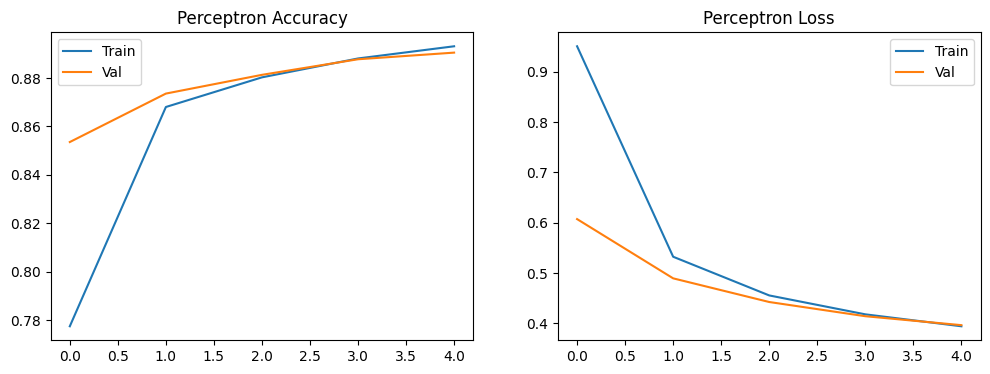

In [28]:

plot_training(history_percp, "Perceptron")

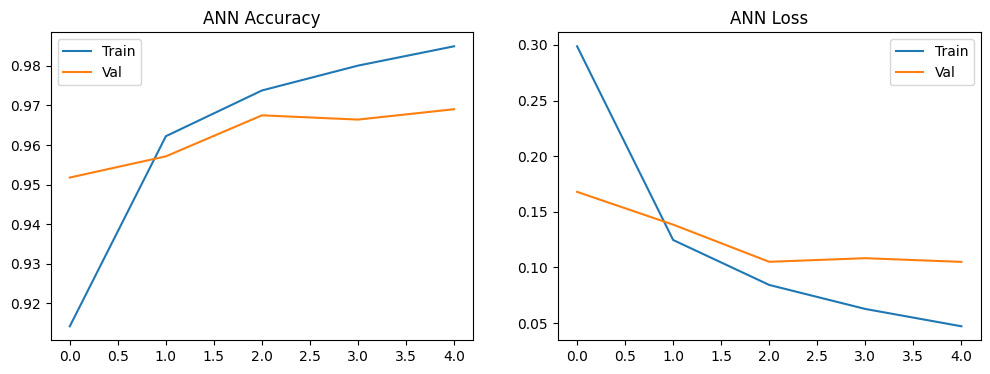

In [29]:
plot_training(history_ann, "ANN")

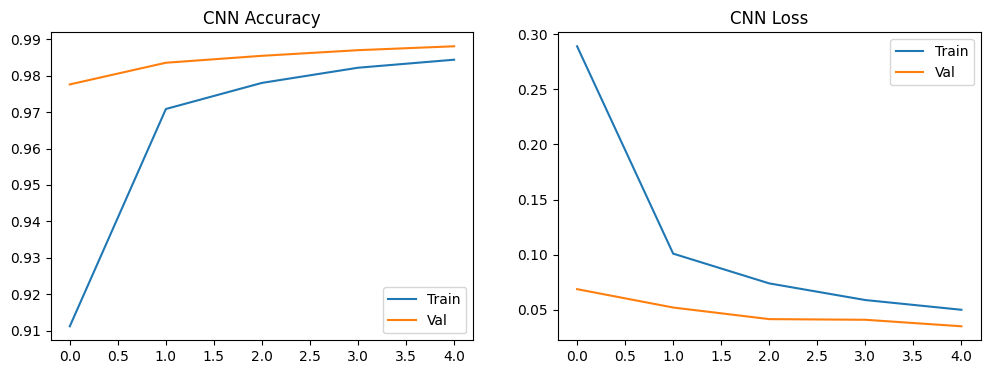

In [30]:
plot_training(history_cnn, "CNN")

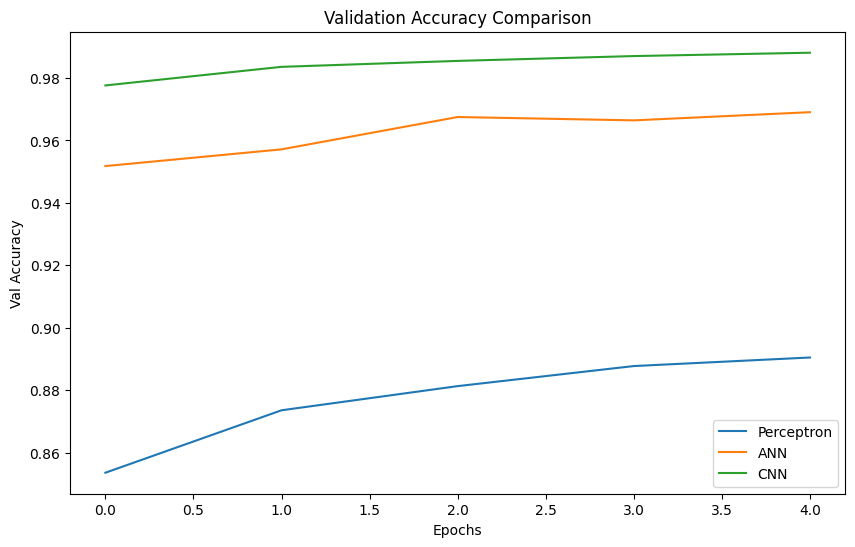

In [31]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [32]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


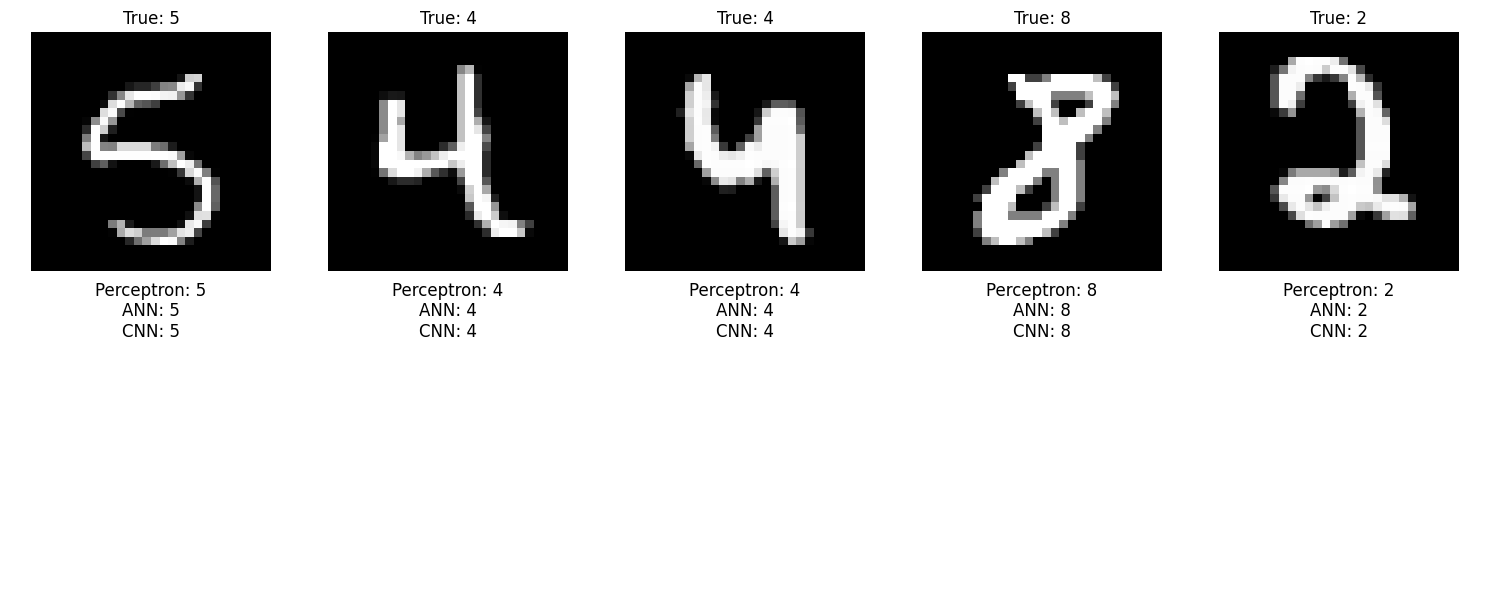

In [33]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


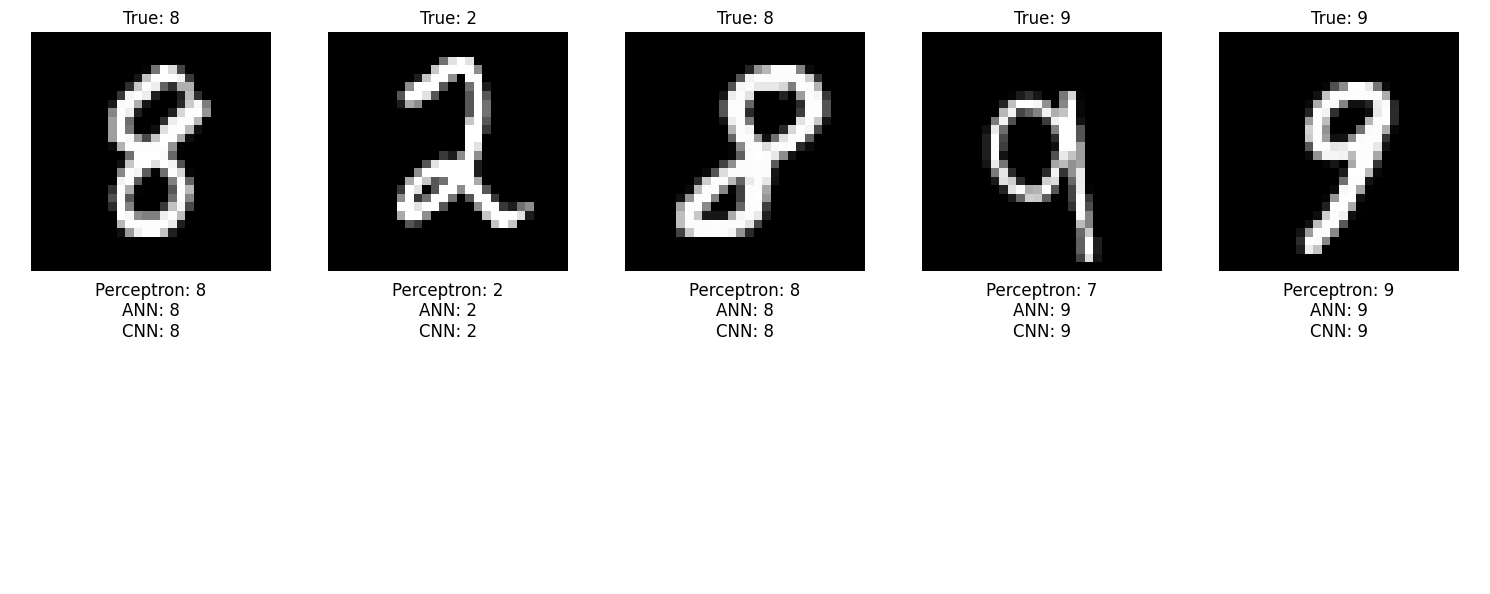

In [34]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


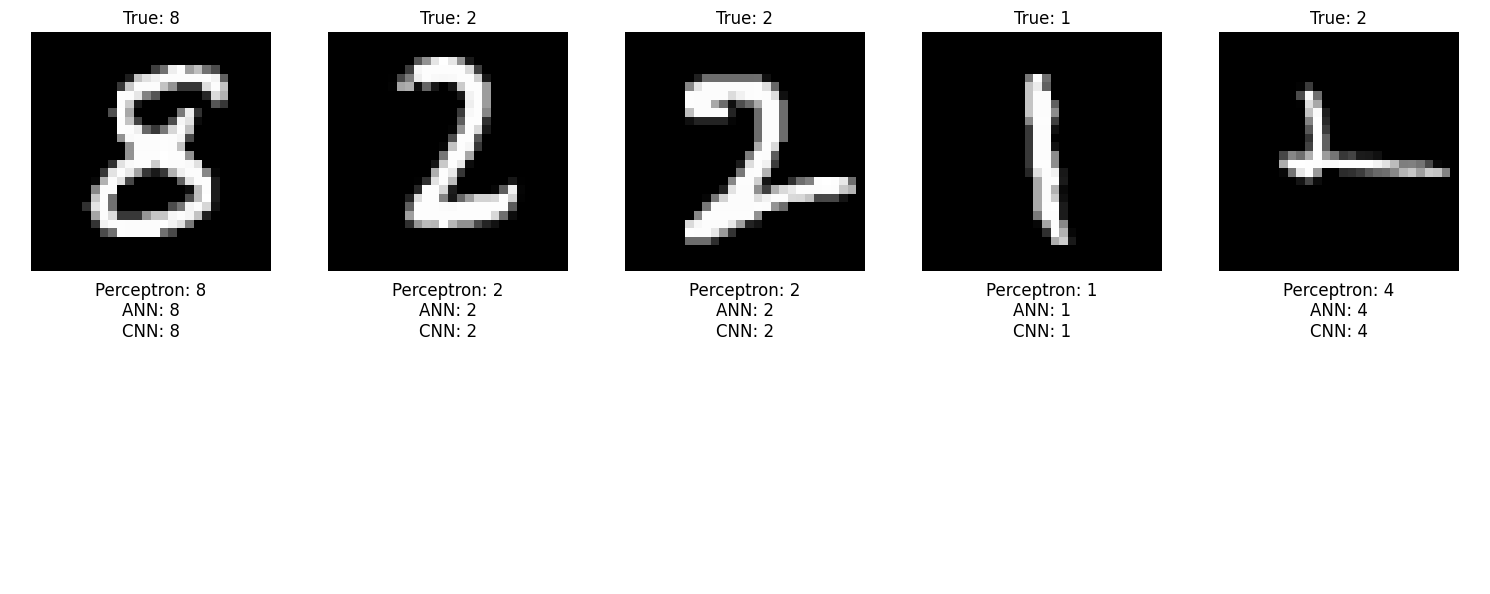

In [35]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)